# Load data

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import polars as pl
import warnings
from datetime import date
import matplotlib.pyplot as plt

In [2]:
(
    pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet('../data/processed/bitcoin_analytics_train.parquet')
)
print("Filtering complete. Saved to bitcoin_analytics_filter.parquet")


Filtering complete. Saved to bitcoin_analytics_filter.parquet


In [3]:
(
    pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2025, 12, 31))
    )
    .sink_parquet('../data/processed/bitcoin_analytics_full_2025.parquet')
)
print("Filtering complete. Saved to bitcoin_analytics_full_2025.parquet")


Filtering complete. Saved to bitcoin_analytics_full_2025.parquet


In [4]:
url = "https://drive.google.com/uc?export=download&id=1SyWrXetOSO37xvV7UWlHI9UZ1447Rzxv"

enriched_bitcoin_analytics_full_2025 = pd.read_parquet(url)
enriched_bitcoin_analytics_full_2025.to_parquet('../data/processed/enriched_bitcoin_analytics_full_2025.parquet')

In [5]:
(
    pl.scan_parquet('../data/processed/enriched_bitcoin_analytics_full_2025.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet('../data/processed/enriched_btc_df_train.parquet')
)
print("Filtering complete. Saved to enriched_btc_df_train.parquet")


Filtering complete. Saved to enriched_btc_df_train.parquet


In [6]:
enriched_btc_df = pd.read_parquet("../data/processed/enriched_btc_df_train.parquet")

# Tunable strategy: first come first served

In [ ]:
from stacksats import StrategyRunner, BacktestConfig
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy 

enriched_btc_df = pd.read_parquet('../data/processed/enriched_bitcoin_analytics_full_2025.parquet')
enriched_btc_df = pl.from_pandas(enriched_btc_df).with_columns(pl.col('date').cast(pl.Datetime))

# ---------------------------------------------------------
# 1. Feature Engineering (Macro Variables)
# ---------------------------------------------------------
# Calculate the 90-day percentage change in Treasury Yields -> 90-day because its = 1 financial quarter of 3 months
if 'Treasury_90d_Delta' not in enriched_btc_df.columns:
    enriched_btc_df = enriched_btc_df.with_columns(
        ((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta')
    )

# ---------------------------------------------------------
# 2. The Master Multi-Factor Strategy
# ---------------------------------------------------------
class TunableMasterStrategy(BaseStrategy):
    def __init__(self, macro_spike, mom_break, boost, dampen):
        self.macro_spike = macro_spike
        self.mom_break = mom_break
        self.boost = boost
        self.dampen = dampen
        
        # Dynamic cache-busting ID
        self.strategy_id = f"master_{macro_spike}_{mom_break}_{boost}_{dampen}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        # Pull the global macro data we just created
        global enriched_btc_df
        macro_subset = enriched_btc_df.select(['date', 'Treasury_90d_Delta', 'MOM15', 'price_usd'])
        
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        merged = base_scores.join(macro_subset, on='date', how='inner')
        
        # We need the 1-year lookback for YOUR Value-Floor Strategy
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        
        # --- THE MASTER RULES ---
        # 1. MACRO CRASH (Fed Tightening + Momentum Dying)
        condition_macro_crash = (
            (pl.col('Treasury_90d_Delta') >= self.macro_spike) & 
            (pl.col('MOM15') <= self.mom_break)
        )
        
        # 2. YOUR VALUE CRASH (Price down 60% from last year)
        condition_value_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.4)
        
        # 3. GOLDEN CROSS (Fed Easing + Momentum Rising)
        condition_golden = (
            (pl.col('Treasury_90d_Delta') <= 0.0) & 
            (pl.col('MOM15') >= 0.0)
        )
                
        merged = merged.with_columns(
            pl.when(condition_value_crash)
            .then(
                # TIER 1: Normal market crash. Buy the blood! (Takes absolute priority)
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.6)) 
            )
            .when(condition_macro_crash)
            .then(
                # TIER 2: Fed is draining liquidity. DO NOT BUY! Hoard cash!
                pl.lit(0.00001) 
            )
            .when(condition_golden)
            .then(
                # TIER 3: Macro environment is perfect. Boost the MVRV!
                pl.max_horizontal(pl.col('preference') * self.boost, pl.lit(0.4))
            )
            .otherwise(
                # NORMAL MARKET: Dampen MVRV to save cash.
                pl.max_horizontal(pl.col('preference') * self.dampen, pl.lit(0.00001))
            )
            .alias('value')
        )
        
        # Handle the NaNs from the first 365 days by defaulting to neutral (0.5)
        return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)


# Test

In [8]:
from stacksats import UniformStrategy, MVRVStrategy, ExportConfig

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Master Macro Strategy (2018-2023)...")

# We pick one combination to test manually!
master_strat = TunableMasterStrategy(macro_spike=0.30, mom_break=-0.05, boost=3.0, dampen=0.2)

# Notice we use `enriched_btc_df` so the Macro data is included!
macro_result = runner.backtest(master_strat, config)
uni_result = runner.backtest(UniformStrategy(), config)
mvrv_result = runner.backtest(MVRVStrategy(), config)

print(f"-> Master Macro Score: {macro_result.score:.2f}")
print(f"-> Master Macro Win Rate: {macro_result.win_rate:.1f}%")
print(f"-> Master Macro Exponential decay percentile: {macro_result.exp_decay_percentile:.1f}%")

print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> MVRV Exponential decay percentile: {mvrv_result.exp_decay_percentile:.1f}%")

print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(master_strat, export_config).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config).to_dataframe()
    base = runner.export(UniformStrategy(), export_config).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Master Macro Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

Running New Master Macro Strategy (2018-2023)...
-> Master Macro Score: 37.14
-> Master Macro Win Rate: 66.3%
-> Master Macro Exponential decay percentile: 7.9%
-> MVRV Score: 23.51
-> MVRV Win Rate: 41.8%
-> MVRV Exponential decay percentile: 5.2%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Master Macro Strategy): 47,739 Sats
Total Sats (MVRV Strategy): 47,815 Sats
Total Sats (Uniform DCA): 50,551 Sats


In [ ]:
runner = StrategyRunner()

config = BacktestConfig(start_date="2024-01-01", end_date="2025-12-31")

mvrv_result = runner.backtest(master_strat, config)
define_Result = runner.backtest(MVRVStrategy(), config)

print(f"-> default backtest:  {mvrv_result.score:.2f}% | Win Rate: {mvrv_result.win_rate:.1f}% | Exp-Decay: {mvrv_result.exp_decay_percentile:.1f}%")
print(f"-> defined dataset backtest:  {define_Result.score:.2f}% | Win Rate: {define_Result.win_rate:.1f}% | Exp-Decay: {define_Result.exp_decay_percentile:.1f}%")

# Graph

In [ ]:

# fig, axes = plt.subplots(3, 2, figsize=(15, 9))
# axes = axes.flatten()

# for i, year in enumerate(range(2018, 2024)):
#     year_data = merged_sats.filter(pl.col('year') == year).sort('date')
    
#     ax1 = axes[i]
#     # Create the twin axis for the weights
#     ax2 = ax1.twinx()
    
#     # 1. Plot the Bitcoin Price on the Left Axis (Black Line)
#     ax1.plot(year_data['date'], year_data['price_usd'], color='black', linewidth=2, label='BTC Price ($)')
    
#     # 2. Plot the Strategy Weights on the Right Axis
#     ax2.plot(year_data['date'], year_data['dynamic_weight'], color='tab:green', label='Master Macro Weight', linewidth=2.5, alpha=0.9)
#     ax2.plot(year_data['date'], year_data['mvrv_weight'], color='tab:purple', label='MVRV strat', linewidth=1.5, alpha=0.6)
#     ax2.plot(year_data['date'], year_data['baseline_weight'], color='tab:orange', label='Baseline DCA strat', linestyle='--', linewidth=2)
    
#     ax1.set_title(f'BTC Price vs Strategy Allocations ({year})', fontsize=14, fontweight='bold')
#     ax1.set_ylabel('BTC Price ($)', color='black', fontweight='bold')
#     ax2.set_ylabel('Daily Buy Weight', color='tab:green', fontweight='bold')
    
#     # Combine the legends from both axes so they look clean
#     lines_1, labels_1 = ax1.get_legend_handles_labels()
#     lines_2, labels_2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

# plt.tight_layout()
# plt.show()

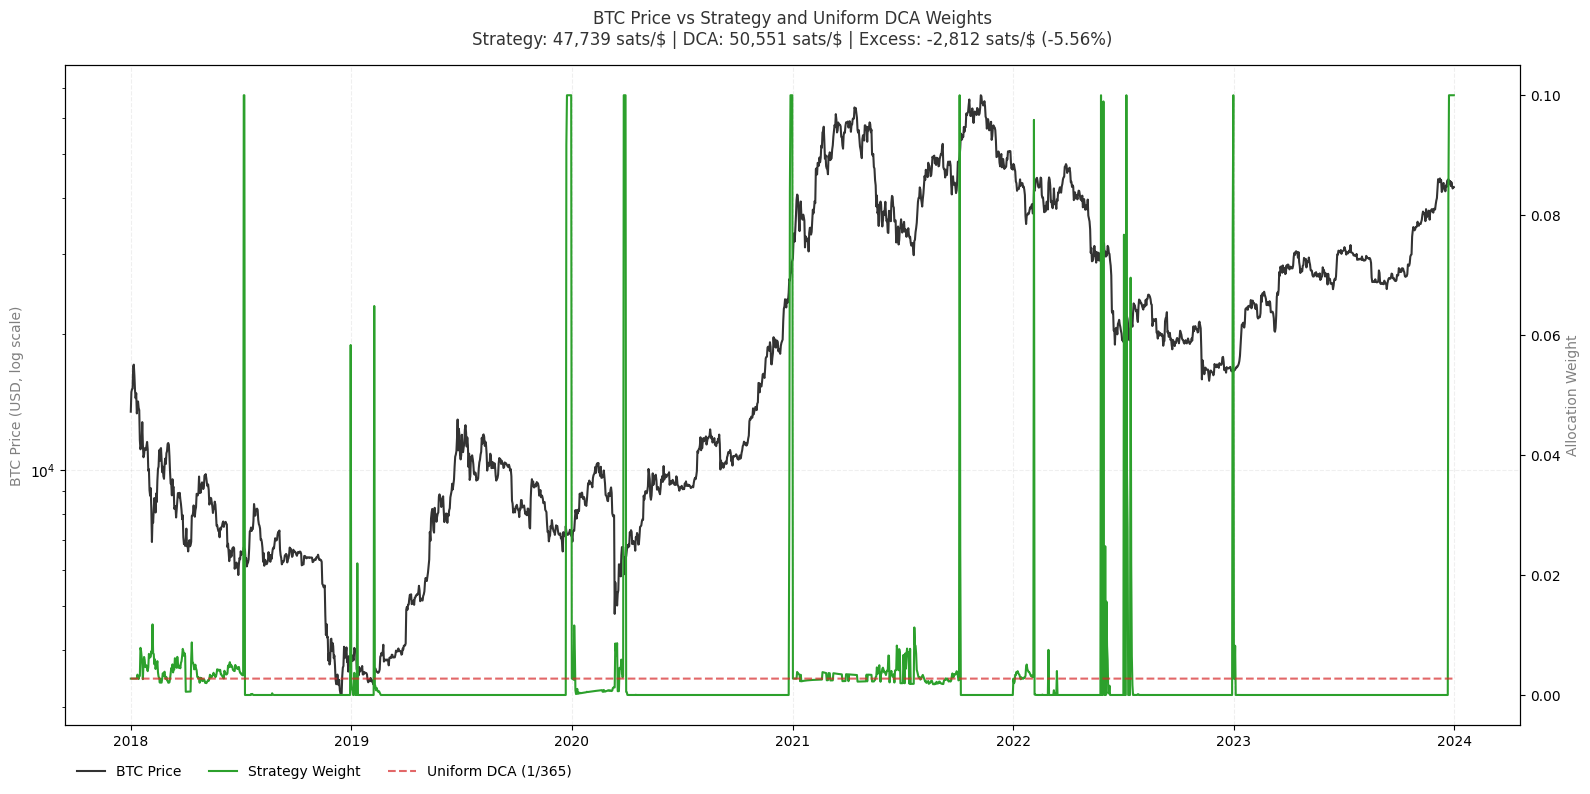

In [11]:

# 1. Sort the data perfectly by date to prevent criss-crossing
merged_sats = merged_sats.sort('date')

# 2. Calculate Sats for the entire dataset
strat_sats = merged_sats['sats_accumulated_dynamic'].sum()
base_sats = merged_sats['sats_accumulated_baseline'].sum()
diff = strat_sats - base_sats
pct = (diff / base_sats) * 100 if base_sats > 0 else 0

# Create the beautiful, single-line Title Text
title_text = (
    "BTC Price vs Strategy and Uniform DCA Weights\n"
    f"Strategy: {strat_sats:,.0f} sats/$ | DCA: {base_sats:,.0f} sats/$ | "
    f"Excess: {'+' if diff > 0 else ''}{diff:,.0f} sats/$ ({'+' if pct > 0 else ''}{pct:.2f}%)"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Plot Price on Left Axis (LOG SCALE)
ax1.plot(merged_sats['date'], merged_sats['price_usd'], color='black', linewidth=1.5, label='BTC Price', alpha=0.8)
ax1.set_yscale('log')
ax1.set_ylabel('BTC Price (USD, log scale)', color='gray')

# Plot Weights on Right Axis (LINEAR SCALE)
ax2.plot(merged_sats['date'], merged_sats['dynamic_weight'], color='tab:green', linewidth=1.5, label='Strategy Weight')
ax2.plot(merged_sats['date'], merged_sats['baseline_weight'], color='tab:red', linestyle='--', linewidth=1.5, label='Uniform DCA (1/365)', alpha=0.7)
ax2.set_ylabel('Allocation Weight', color='gray')

# Formatting
plt.title(title_text, fontsize=12, pad=15, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='--')

# Combine Legends at the bottom
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, -0.1))

plt.tight_layout()
plt.show()


# Math

This is the absolute core of your Capstone project! You need to be able to explain this math clearly to your professors. 

Think of this code as a **4-Tier Mathematical Hierarchy**. The algorithm checks the rules in order from top to bottom. As soon as one rule is True, it executes the math and skips the rest.

Here is exactly how the math works for each rule:

### 1. The Triggers (The Inputs)
Before making a decision, the algorithm calculates three metrics:
* **`Treasury_90d_Delta`**: Calculates the percentage change in the 10-Year Treasury Yield over 90 days. `(Today / 90_days_ago) - 1`. If the yield goes from 2.0% to 2.6%, the delta is `0.30` (a 30% spike).
* **`MOM15`**: Calculates Bitcoin's 15-day price momentum.
* **`price_1y_ago`**: Looks at the exact price of Bitcoin 365 days ago.

### 2. The 4-Tier Logic Hierarchy (The Multipliers)
Every single day, the algorithm evaluates these tiers in order:

**Tier 1: The Macro Veto (The Panic Button)**
* **The Math:** If `Treasury_90d_Delta >= 0.30` AND `MOM15 <= -0.05`.
* **The Action:** Output `0.00001`. 
* **Explanation:** The Federal Reserve is aggressively attacking the economy, and Bitcoin is already bleeding. The algorithm overrides everything else and sets the buy weight to essentially zero. It hoards cash.

**Tier 2: The Value Crash (The Mega-Buy)**
* **The Math:** If `price_usd <= (price_1y_ago * 0.4)`. 
* **The Action:** `max_horizontal(preference * 2.0, 0.6)`. 
* **Explanation:** If Bitcoin has dropped 60% from last year, there is massive blood in the streets. It takes the normal MVRV score (`preference`), multiplies it by 2, and guarantees it will *never* drop below a massive `0.6` floor. It buys with both hands.

**Tier 3: The Golden Cross (The Bull Market)**
* **The Math:** If `Treasury_90d_Delta <= 0` (rates are dropping) AND `MOM15 >= 0` (trend is up).
* **The Action:** `max_horizontal(preference * 3.0, 0.4)`.
* **Explanation:** Liquidity is flowing into the market, and the trend is your friend. It triples the MVRV score and guarantees a solid `0.4` floor.

**Tier 4: The Normal Market (The Piggy Bank)**
* **The Math:** If nothing exciting is happening.
* **The Action:** `max_horizontal(preference * 0.2, 0.00001)`.
* **Explanation:** It takes the normal MVRV score and slashes it by 80% (`* 0.2`). It is intentionally "cheap" during boring markets so it can build up a massive pile of cash for the next crash.

### 3. The Normalization Engine (The Hidden Math)
The most important thing to know is that `0.6` or `0.00001` are **NOT** the actual dollar amounts spent! 

The framework takes all of these raw scores and mathematically **normalizes** them across a rolling 365-day window so that they always sum to $365 a year. 
Because Tier 4 (`0.00001`) artificially suppresses the math for months at a time, it builds up massive "stored budget". When Tier 2 (`0.6`) finally triggers, the normalization math acts like a dam breaking, unleashing all of that stored cash into the market in a massive geyser!

# Tuning

In [ ]:
# import polars as pl

# # The parameter ranges
# macro_spikes  = [0.10, 0.20, 0.30]   
# mom_breaks    = [-0.05, 0.0, 0.05]   
# boosts        = [2.0, 3.0]           
# dampens       = [0.1, 0.2]           

# leaderboard = []

# print(f"Starting Multi-Objective Grid Search (Win Rate + Total Sats)...")
# print("This calculates 216 individual years of data. It will take ~2 minutes. Grab a coffee!")

# for ms in macro_spikes:
#     for mb in mom_breaks:
#         for b in boosts:
#             for d in dampens:
                
#                 strat = TunableMasterStrategy(macro_spike=ms, mom_break=mb, boost=b, dampen=d)
                
#                 # 1. Get the Win Rate Consistency (Backtest Engine)
#                 result = runner.backtest(strat, config, btc_df=enriched_btc_df)
#                 win_rate = float(result.win_rate)
                
#                 # 2. Get the Absolute Profit (Export Engine)
#                 macro_dynamic = []
#                 for year in range(2018, 2024):
#                     export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
#                     dyn = runner.export(strat, export_config, btc_df=enriched_btc_df).to_dataframe()
                    
#                     dyn_flat = dyn.group_by('date').agg([
#                         pl.col('weight').mean().alias('dynamic_weight'),
#                         pl.col('price_usd').first()
#                     ])
#                     macro_dynamic.append(dyn_flat)
                
#                 dynamic_weights = pl.concat(macro_dynamic)
                
#                 # Calculate the raw Sats
#                 total_sats = (dynamic_weights['dynamic_weight'] / dynamic_weights['price_usd'] * 100_000_000).sum()
                
#                 # Save both metrics!
#                 leaderboard.append({
#                     "Macro_Spike": ms,
#                     "Mom_Break": mb,
#                     "Boost": b,
#                     "Dampen": d,
#                     "Win_Rate": win_rate,
#                     "Total_Sats": total_sats
#                 })

# # Convert to DataFrame
# results_df = pl.DataFrame(leaderboard)

# # THE HOLY GRAIL FILTER: 
# # 1. Must have > 50% Win Rate (Consistent Risk-Adjustment)
# # 2. Must beat the Baseline DCA of 50,551 Sats (Profitable Absolute Return)
# holy_grail_df = results_df.filter(
#     (pl.col("Win_Rate") > 50.0) & 
#     (pl.col("Total_Sats") > 50551)
# ).sort("Total_Sats", descending=True)

# print("\n🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆")
# display(holy_grail_df)

# print("\n📊 ALL RESULTS (Sorted by Total Sats) 📊")
# display(results_df.sort("Total_Sats", descending=True).head(10))


Starting Multi-Objective Grid Search (Win Rate + Total Sats)...
This calculates 216 individual years of data. It will take ~2 minutes. Grab a coffee!

🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆


Macro_Spike,Mom_Break,Boost,Dampen,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64



📊 ALL RESULTS (Sorted by Total Sats) 📊


Macro_Spike,Mom_Break,Boost,Dampen,Win_Rate,Total_Sats
f64,f64,f64,f64,f64,f64
0.3,-0.05,2.0,0.2,57.525999,49820.476781
0.3,0.0,2.0,0.2,57.252326,49804.272378
0.3,0.05,2.0,0.2,55.446086,49802.867348
0.2,-0.05,2.0,0.2,57.252326,49796.579785
0.2,0.0,2.0,0.2,53.256705,49768.730035
0.2,0.05,2.0,0.2,49.534756,49761.052926
0.1,-0.05,2.0,0.2,56.431308,49631.566967
0.1,0.0,2.0,0.2,49.589491,49600.232664
0.1,0.05,2.0,0.2,46.524357,49559.794141
